In [1]:
import numpy as np
coindomain = [0, 1]
coinprob = [0.5, 0.5]

np.random.choice(coindomain, size = 10, replace = True, p = coinprob)

array([1, 0, 1, 0, 0, 0, 1, 0, 0, 1])

In [2]:
diedomain = range(1,7)
dieprob = np.repeat(1/6, 6)

np.random.choice(diedomain, size = 15, replace=True, p = dieprob)

array([5, 4, 5, 6, 5, 1, 2, 4, 1, 4, 5, 6, 2, 2, 6])

In [10]:
import pandas as pd

res1 = np.random.choice(coindomain, size = 5, replace = True, p = coinprob)
pd.DataFrame(data = res1).value_counts(normalize = True)

0
0    0.6
1    0.4
Name: proportion, dtype: float64

In [12]:
res1 = np.random.choice(coindomain, size = 1000, replace = True, p = coinprob)
pd.DataFrame(data = res1).value_counts(normalize = True)

0
1    0.539
0    0.461
Name: proportion, dtype: float64

In [13]:
res1 = np.random.choice(coindomain, size = 100000, replace = True, p = coinprob)
pd.DataFrame(data = res1).value_counts(normalize = True)

0
0    0.50394
1    0.49606
Name: proportion, dtype: float64

In [15]:
coindomain = [0, 1]
coinprob = [0.5, 0.5]

def f1(coindomain, coinprob):
    y = np.random.choice(coindomain, size = 50, replace = True, p = coinprob)
    return sum(y)

val = f1(coindomain, coinprob)
print(val)

28


In [17]:
s1 = [f1(coindomain, coinprob) for _ in range(10000)]
edf1 = pd.DataFrame(data = s1).value_counts(normalize=True).sort_index(ascending=True)
edf1

0 
10    0.0001
12    0.0001
13    0.0002
14    0.0009
15    0.0021
16    0.0041
17    0.0089
18    0.0176
19    0.0271
20    0.0427
21    0.0619
22    0.0815
23    0.0963
24    0.1022
25    0.1123
26    0.1122
27    0.0931
28    0.0826
29    0.0603
30    0.0374
31    0.0238
32    0.0172
33    0.0091
34    0.0035
35    0.0018
36    0.0006
37    0.0004
Name: proportion, dtype: float64

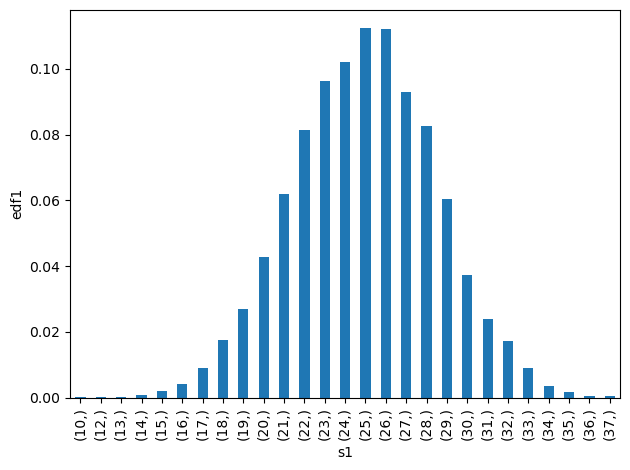

In [18]:
ax = edf1.plot(kind = 'bar')
ax.set_xlabel('s1')
ax.set_ylabel('edf1')
ax.get_figure().tight_layout()

In [20]:
print("Head <= 20 : ", len([i for i in s1 if i <= 20]) / len(s1))
print("Head >= 15 : ", len([i for i in s1 if i >= 15]) / len(s1))

Head <= 20 :  0.1038
Head >= 15 :  0.9987


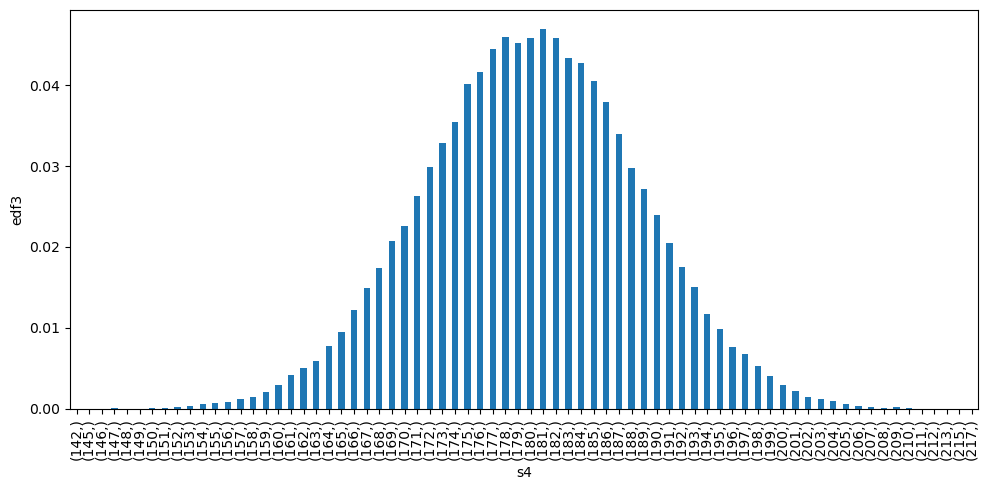

In [ ]:
# 0 - drug wont cure the patient
# 1 - drug will cure the patient
drugdomain = [0, 1]

def f2(sz, successprob):
    drugprob = [1-successprob, successprob]
    v2 = np.random.choice(drugdomain, size = sz, replace = True, p = drugprob)
    s3 = sum(v2)
    return s3

s4 = [f2(sz = 300, successprob = 0.6) for _ in range(100000)]
edf2 = pd.DataFrame(data = s4).value_counts(normalize=True).sort_index(ascending=True)

ax = edf2.plot(kind = 'bar', figsize = (10, 5))
ax.set_xlabel('s4')
ax.set_ylabel('edf3')

ax.get_figure().tight_layout() 

In [22]:
len([i for i in s4 if i <= 160])/len(s4)

0.01093

In [23]:
ddomain = np.array(range(1,5))
dprob = [0.7, 0.1, 0.1, 0.1]

meandistribution = sum(ddomain*dprob)
print("Mean of the distribution: ", meandistribution)

vardistribution = sum((dprob)*(ddomain - meandistribution)**2)
print("Variance of the distribution: ", vardistribution)

Mean of the distribution:  1.6
Variance of the distribution:  1.04


<Figure size 800x600 with 0 Axes>

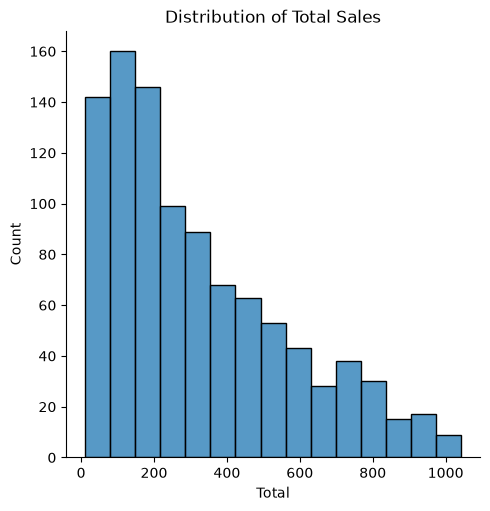

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('supermarket.csv')

plt.figure(dpi = 125)
sns.displot(df['Total'], kde = False)
plt.title('Distribution of Total Sales')
plt.show()

<Figure size 800x600 with 0 Axes>

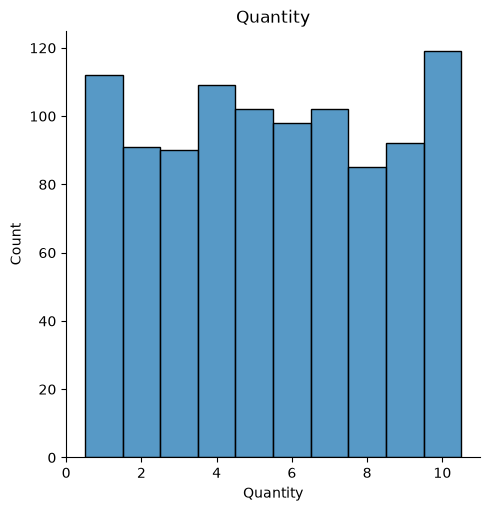

In [17]:
plt.figure(dpi = 125)
sns.displot(df['Quantity'], bins=np.arange(0.5, 11.5, 1), kde = False)
plt.title('Quantity')
plt.show()

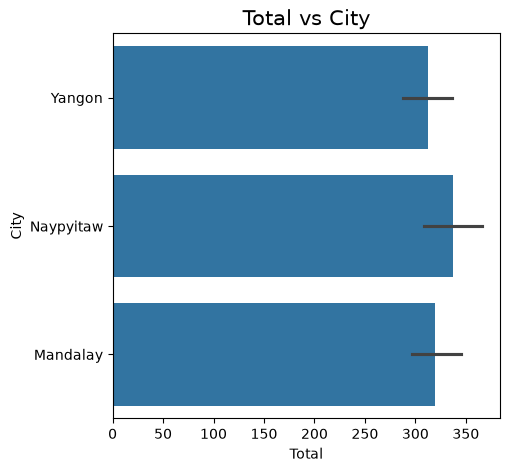

In [18]:
plt.style.use("default")

plt.figure(figsize = (5,5))
sns.barplot(x = 'Total', y = 'City', data = df)
plt.title("Total vs City", fontsize = 15)
plt.xlabel('Total')
plt.ylabel('City')
plt.show()

In [21]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


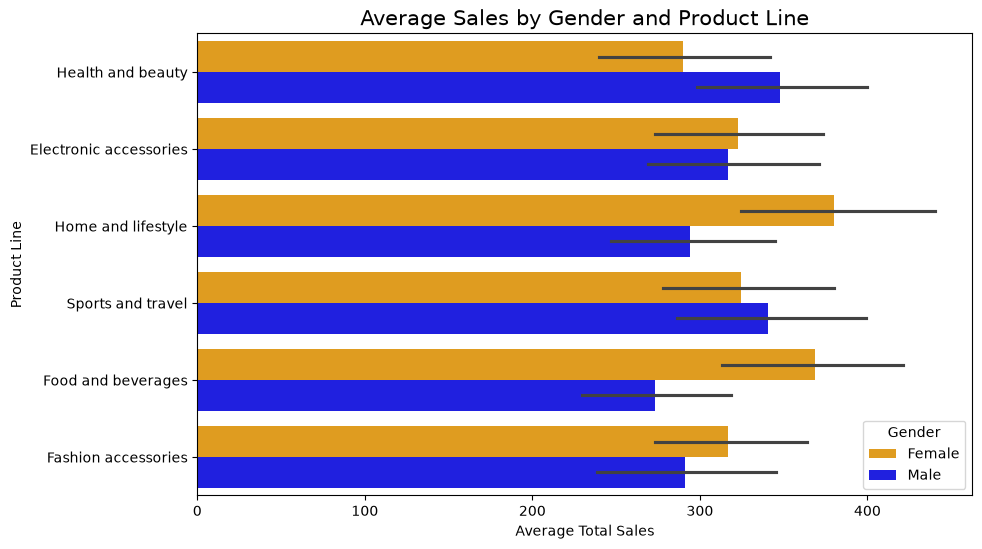

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(x='Total', y='Product line', hue='Gender', data=df, palette={'Male': 'blue', 'Female': 'orange'})

plt.title('Average Sales by Gender and Product Line', fontsize=15)
plt.xlabel('Average Total Sales')
plt.ylabel('Product Line')

plt.show()